In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [35]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

In [272]:
ndimage = pyimport("scipy.ndimage") 

PyObject <module 'scipy.ndimage' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/scipy/ndimage/__init__.py'>

In [42]:
Energies = zeros(20, 20)
for i in 1:20
    for j in 1:20
        try
        Energies[i, j] = list_energy("Moire-$i-$j.out")
        catch e
            println(e)
        end
    end
end

In [21]:
v1, v2, v3 = loadlattice("Moire-1-1.out");

In [31]:
det(hcat(v1, v2, v3))/7/sqrt(sum(v3.*v3))/(1.44*1.4*3*sqrt(3)/2)

1.006043669360986

In [23]:
sum(v1 .* v2)/sum(v1.*v1)

-0.5000013378236597

In [187]:
lattice_to_cartesian = 
[ -11.8187  2.36374;  4.09412  -12.2824 ] .*235/20/sqrt((-11.818700)^2+4.09412^2)

2×2 Matrix{Float64}:
 -11.1027     2.22054
   3.84609  -11.5383

In [188]:
cartesian_to_lattice = inv(lattice_to_cartesian)

2×2 Matrix{Float64}:
 -0.0965016  -0.0185717
 -0.0321671  -0.0928583

In [289]:
zEnergies = zscore(Energies);

In [190]:
function returnE(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_lattice*x)) 
    i, j = rem.([i, j], 20)
    i < 0 && (i = i+20)
    j < 0 && (j = j+20)
    return (zEnergies[i+1, j+1])
end

returnE (generic function with 1 method)

In [305]:
N=400
EnergyArray = zeros(N, N)
for i in 1:N
    for j in 1:N
        r=[i, j]-[115, -27]
        EnergyArray[i, j] = returnE(r)
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

In [306]:
Moire_Fig = imread("Moire.jpg");

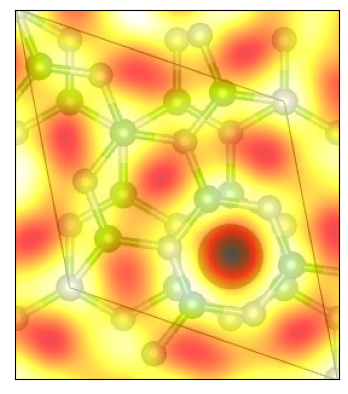

(Any[], Any[])

In [309]:
imshow(Moire_Fig, alpha=1, cmap="hot")
img = ndimage.gaussian_filter(np.rot90(EnergyArray), sigma=10)
imshow(img, cmap="hot", alpha=0.7)

ylim(377, 71)
xlim(112, 380)
xticks(Float64[])
yticks(Float64[])
#imshow(np.rot90(EnergyArray), interpolation="gaussian", cmap="hot", alpha=0.1)

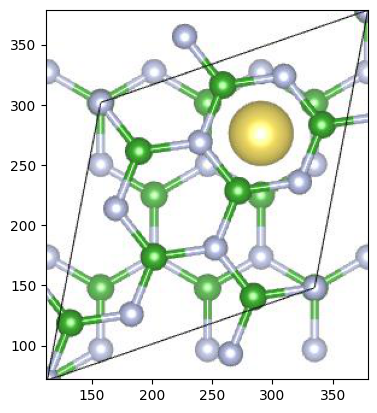

(112.0, 379.0)

In [164]:
imshow(Moire_Fig, alpha=0.95, cmap="Blues")
ylim(72, 379)
xlim(112, 379)

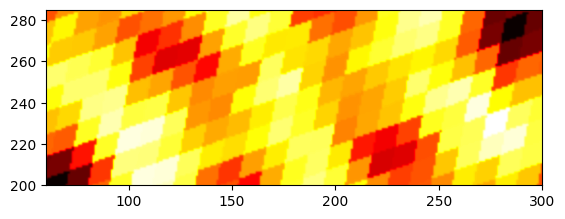

(200.0, 285.0)

In [263]:
imshow(np.rot90(EnergyArray), interpolation="gaussian", cmap="hot", alpha=1)
xlim(60, 300)
ylim(200, 285)

400×400 Matrix{Float64}:
 1.27817   1.26595   1.24169   1.2057    …  0.154734  0.139118  0.131085
 1.28112   1.26909   1.2452    1.20976      0.163776  0.148612  0.140818
 1.2863    1.27463   1.25145   1.21704      0.181597  0.167333  0.160013
 1.2924    1.28122   1.25899   1.226        0.207642  0.194709  0.188092
 1.29774   1.28711   1.26599   1.23465      0.241002  0.229801  0.224097
 1.30053   1.29045   1.27046   1.24082   …  0.280374  0.27125   0.266642
 1.29914   1.28956   1.27059   1.24254      0.324061  0.317281  0.313908
 1.29234   1.28315   1.26499   1.23826      0.370048  0.365769  0.363714
 1.27947   1.2705    1.25286   1.22706      0.416133  0.414386  0.413665
 1.26044   1.25152   1.23405   1.20871      0.460122  0.460802  0.461357
 1.23572   1.22666   1.20902   1.18365   …  0.500045  0.502911  0.504616
 1.20616   1.19679   1.17865   1.15282      0.534342  0.539042  0.54171
 1.17277   1.16298   1.14411   1.11747      0.562009  0.568105  0.571504
 ⋮                         

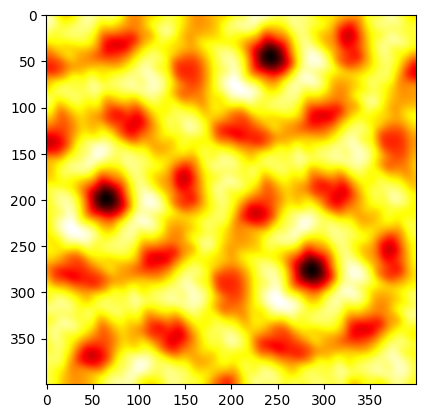

PyObject <matplotlib.image.AxesImage object at 0x7fe3f669c760>

In [282]:
imshow(img, cmap="hot")

In [276]:
?ndimage.gaussian_filter

Multidimensional Gaussian filter.

    Parameters
    ----------
    input : array_like
        The input array.
    sigma : scalar or sequence of scalars
        Standard deviation for Gaussian kernel. The standard
        deviations of the Gaussian filter are given for each axis as a
        sequence, or as a single number, in which case it is equal for
        all axes.
    order : int or sequence of ints, optional
        The order of the filter along each axis is given as a sequence
        of integers, or as a single number. An order of 0 corresponds
        to convolution with a Gaussian kernel. A positive order
        corresponds to convolution with that derivative of a Gaussian.
    output : array or dtype, optional
        The array in which to place the output, or the dtype of the
        returned array. By default an array of the same dtype as input
        will be created.
    mode : str or sequence, optional
        The `mode` parameter determines how the input array is 